=== REGIONAL PERFORMANCE ===
 region      Revenue       Profit  Orders  Customers     Avg_Order  Margin_%
  North 1.460577e+09 626542119.35    3050       2128 478877.589275     42.90
   West 1.414856e+09 592721882.73    3000       2107 471618.754850     41.89
Central 1.369235e+09 580073094.80    2945       2107 464935.343976     42.36
  South 1.354496e+09 582098498.29    3023       2125 448063.529785     42.98
   East 1.329791e+09 567647129.62    2982       2129 445939.382700     42.69


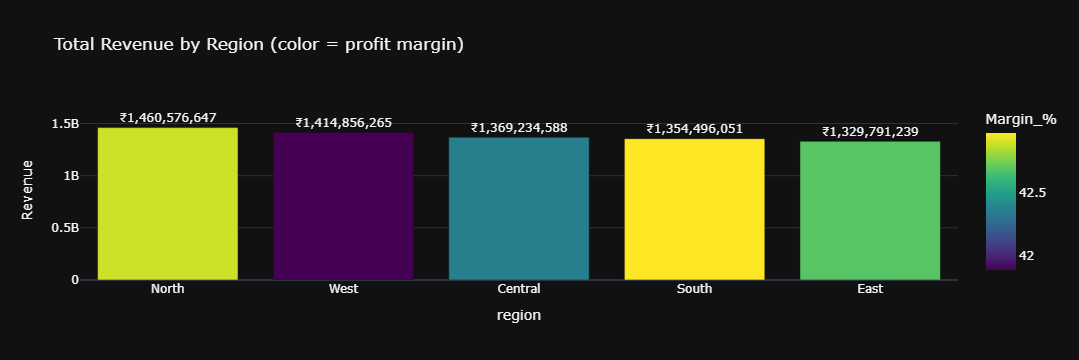

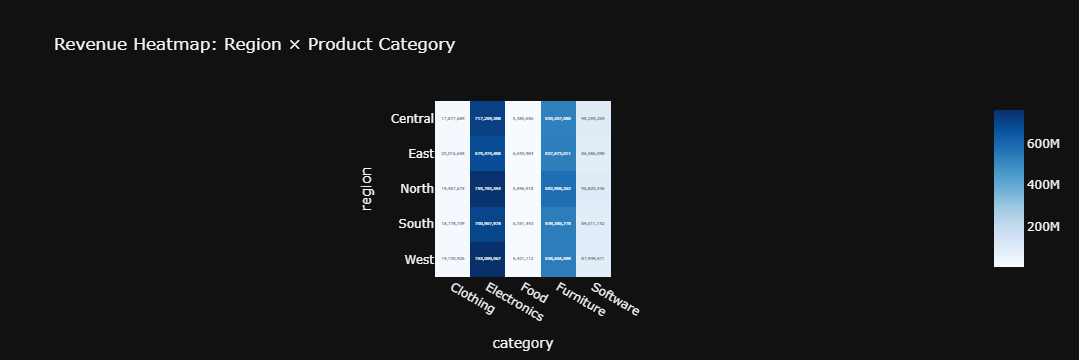

C:\Users\admin\AppData\Local\Temp\ipykernel_4820\2565100158.py:55: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby([pd.Grouper(key='date', freq='M'), 'region'])['revenue']


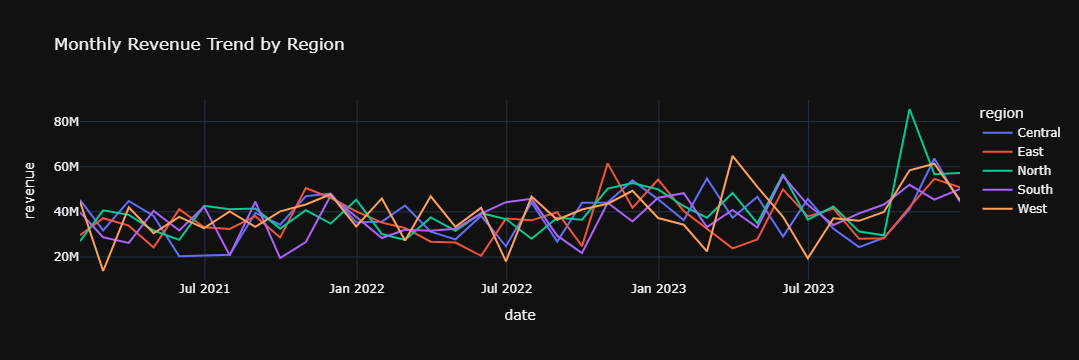

✅ Region analysis complete!


In [1]:
# ============================================================
#  NOTEBOOK 06 — Regional Performance Analysis
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = pd.read_csv('../data/processed/sales_clean.csv', parse_dates=['date'])

# ── Regional Summary ──────────────────────────────────────
region_summary = (
    df.groupby('region').agg(
        Revenue    = ('revenue', 'sum'),
        Profit     = ('profit', 'sum'),
        Orders     = ('transaction_id', 'count'),
        Customers  = ('customer_id', 'nunique'),
        Avg_Order  = ('revenue', 'mean'),
    ).reset_index()
)
region_summary['Margin_%'] = (
    region_summary['Profit'] / region_summary['Revenue'] * 100
).round(2)
region_summary = region_summary.sort_values('Revenue', ascending=False)

print("=== REGIONAL PERFORMANCE ===")
print(region_summary.to_string(index=False))

# ── Chart 1: Revenue by Region Bar ───────────────────────
fig1 = px.bar(
    region_summary, x='region', y='Revenue',
    color='Margin_%', color_continuous_scale='viridis',
    text='Revenue', template='plotly_dark',
    title='Total Revenue by Region (color = profit margin)'
)
fig1.update_traces(texttemplate='₹%{text:,.0f}', textposition='outside')
fig1.show()

# ── Chart 2: Region × Category Heatmap ───────────────────
pivot = df.pivot_table(
    values='revenue', index='region', columns='category', aggfunc='sum'
).round(0)

fig2 = px.imshow(
    pivot, text_auto=',.0f',
    color_continuous_scale='Blues', template='plotly_dark',
    title='Revenue Heatmap: Region × Product Category'
)
fig2.show()

# ── Chart 3: Monthly trend by region ─────────────────────
region_monthly = (
    df.groupby([pd.Grouper(key='date', freq='M'), 'region'])['revenue']
    .sum().reset_index()
)
fig3 = px.line(
    region_monthly, x='date', y='revenue', color='region',
    template='plotly_dark',
    title='Monthly Revenue Trend by Region'
)
fig3.show()
print("✅ Region analysis complete!")